<a href="https://colab.research.google.com/github/OlenaBogoliubova/DATA-LOVE-ACADEMY/blob/main/HW_2_1_%D0%9B%D1%96%D0%BD%D1%96%D0%B9%D0%BD%D0%B0_%D1%80%D0%B5%D0%B3%D1%80%D0%B5%D1%81%D1%96%D1%8F_%D0%B2%D1%96%D0%B4_%D0%B1%D0%B0%D0%B3%D0%B0%D1%82%D1%8C%D0%BE%D1%85_%D0%B7%D0%BC%D1%96%D0%BD%D0%BD%D0%B8%D1%85_Bogoliubova.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

В цьому домашньому завданні ми з вами побудуємо повноцінне ML-рішення реальної ML-задачі. Ви вже маєте всі знання, які для цього потрібні. Дотримуйтесь інструкцій, та користуйтесь матеріалами лекцій, аби виконувати завдання. Тут інструкції будуть детальні, а в подільших завданнях - будуть ставати все менш детальними, аби ви вже починали самостійно структурувати ML-проєкт і до кінця курсу для вас розвʼязати будь-яку ML–задачу було eazy-breezy.

## Dataset

Будемо працювати з набором даних `cars.csv`, який описує автомобілі і їх ціну у індійських рупіях :) Мета - передбачити ціну авто за його характеристиками. Опис набору даних:

| Назва рядка            | Опис                                                                                                                                                 |
|------------------------|--------------------------------------------------------------------------------------------------------------------------------------------------------|
| Car_ID                 | Унікальний ідентифікатор для кожного оголошення про автомобіль.                                                                                         |
| Brand                  | Бренд або виробник автомобіля (наприклад, Toyota, Honda, Ford тощо).                                                                                     |
| Model                  | Модель автомобіля (наприклад, Camry, Civic, Mustang тощо).                                                                                               |
| Year                   | Рік виготовлення автомобіля.                                                                                                                            |
| Kilometers_Driven      | Загальний пробіг автомобіля у кілометрах.                                                                                                               |
| Fuel_Type              | Тип палива, який використовує автомобіль (наприклад, бензин, дизель, електро тощо).                                                                      |
| Transmission           | Тип трансмісії автомобіля (наприклад, механічна, автоматична).                                                                                           |
| Owner_Type             | Кількість попередніх власників автомобіля (наприклад, перший, другий, третій).                                                                           |
| Mileage                | Паливна ефективність автомобіля у кілометрах на літр.                                                                                                   |
| Engine                 | Об'єм двигуна автомобіля в кубічних сантиметрах (CC).                                                                                                   |
| Power                  | Максимальна потужність автомобіля в кінських силах (bhp).                                                                                               |
| Seats                  | Кількість місць в автомобілі.                                                                                                                           |
| Price                  | Вартість автомобіля в INR (індійські рупії), що є цільовою змінною для прогнозування.                                                                   |

# Імпорти

Для зручності рекомендую всі імпорти розмістити тут нагорі, аби коли ви перезавантажували ноутбук, одразу можна було в один запуск клітинки імпортувати всі потрібні бібліотеки.

In [63]:
import pandas as pd
from google.colab import drive
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
import statsmodels.api as sm
from sklearn.preprocessing import OrdinalEncoder
from sklearn import preprocessing
import seaborn as sns

# Знайомство з даними

**Завдання 1.** Завантажте набір даних `cars.csv` в pandas.DataFrame. Виведіть перші 5 записів.

In [28]:
drive.mount('/content/drive')
cars_df = pd.read_csv("drive/MyDrive/DATA LOVE/cars.csv")
cars_df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,Car_ID,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Price
0,1,Toyota,Corolla,2018,50000,Petrol,Manual,First,15,1498,108,5,800000
1,2,Honda,Civic,2019,40000,Petrol,Automatic,Second,17,1597,140,5,1000000
2,3,Ford,Mustang,2017,20000,Petrol,Automatic,First,10,4951,395,4,2500000
3,4,Maruti,Swift,2020,30000,Diesel,Manual,Third,23,1248,74,5,600000
4,5,Hyundai,Sonata,2016,60000,Diesel,Automatic,Second,18,1999,194,5,850000


**Завдання 2.** Виведіть типи даних колонок даних, а також дослідіть, які по факту типи даних мають записи в кожній колонці (тип `object` може містити різні типи даних) і скільки значень є в кожній категоріальній колонці.

Напишіть висновок, скільки в наборі даних числових та категоріальних колонок кожного з трьох різних типів (бінарна, мільтикатегоріальна без порядку, мультикатегоріальна з порядком). Шаблон висновку

```
В наборі даних 10 числових і 10 категоріальних колонок з них
- 2 бінарні (мають лише 2 значення)
- 6 мультикатегоріальних (більше 2х значень) зі значеннями, для яких немає відношення порядку
- 2 колонки, в яких можна встановити відношення порядку (наприклад Small<Medium<Large)
```

Якщо не знаєте, як це зробити з `pandas` - ось підказка, які методи можуть допомогти вам виконати це завдання

- pandas.DataFrame.info()
- pandas.DataFrame.dtypes
- pandas.DataFrame.loc[...]
- pandas.DataFrame.select_dtypes(...)
- pandas.Series.unique()
- pandas.Series.nunique()

Детальніше ознайомитись з кожним ви можете в [документації](https://pandas.pydata.org/docs/reference/frame.html), або написати в окремій клітинці знак питання і назву методу (тільки приберіть це перед здачею, бо перегляд документації - не допомагає зрозуміти дані і хід думок, а Ваша робота - це як презентація замовнику зробленої задачі).


In [4]:
cars_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Car_ID             100 non-null    int64 
 1   Brand              100 non-null    object
 2   Model              100 non-null    object
 3   Year               100 non-null    int64 
 4   Kilometers_Driven  100 non-null    int64 
 5   Fuel_Type          100 non-null    object
 6   Transmission       100 non-null    object
 7   Owner_Type         100 non-null    object
 8   Mileage            100 non-null    int64 
 9   Engine             100 non-null    int64 
 10  Power              100 non-null    int64 
 11  Seats              100 non-null    int64 
 12  Price              100 non-null    int64 
dtypes: int64(8), object(5)
memory usage: 10.3+ KB


In [5]:
cars_df.dtypes

,0
Car_ID,int64
Brand,object
Model,object
Year,int64
Kilometers_Driven,int64
Fuel_Type,object
Transmission,object
Owner_Type,object
Mileage,int64
Engine,int64


In [15]:
# Numeric columns
numeric_cols = cars_df.select_dtypes(include=['int64', 'float64']).columns
print(f"\nNumeric columns ({len(numeric_cols)}):")
print(list(numeric_cols))


Numeric columns (8):
['Car_ID', 'Year', 'Kilometers_Driven', 'Mileage', 'Engine', 'Power', 'Seats', 'Price']


In [16]:
# Categorical columns
object_cols = cars_df.select_dtypes(include=['object']).columns
print(f"\nObject-columns ({len(object_cols)}):")
print(list(object_cols))


Object-columns (5):
['Brand', 'Model', 'Fuel_Type', 'Transmission', 'Owner_Type']


In [18]:
for col in object_cols:
    unique_vals = cars_df[col].unique()
    n_unique = cars_df[col].nunique()
    print(f"--- {col} ---")
    print(f"Number of unique values: {n_unique}")
    print(f"Unique values: {unique_vals}")
    print()

--- Brand ---
Number of unique values: 11
Unique values: ['Toyota' 'Honda' 'Ford' 'Maruti' 'Hyundai' 'Tata' 'Mahindra' 'Volkswagen'
 'Audi' 'BMW' 'Mercedes']

--- Model ---
Number of unique values: 58
Unique values: ['Corolla' 'Civic' 'Mustang' 'Swift' 'Sonata' 'Nexon' 'Scorpio' 'Polo'
 'A4' 'X1' 'C-Class' 'Endeavour' 'Creta' 'Harrier' 'Ertiga' 'City'
 'Tiguan' 'Q3' '5 Series' 'GLC' 'Innova' 'Figo' 'Verna' 'Altroz' 'Thar'
 'Passat' 'A6' 'X3' 'E-Class' 'Fortuner' 'Aspire' 'Elantra' 'Safari'
 'Vitara' 'WR-V' 'Ameo' 'A3' '7 Series' 'GLE' 'Yaris' 'Ranger' 'Santro'
 'Tigor' 'S-Cross' 'BR-V' 'T-Roc' 'Q7' 'X5' 'GLA' 'Camry' 'Venue' 'Tiago'
 'XUV300' 'Vento' 'A5' '3 Series' 'Innova Crysta' 'EcoSport']

--- Fuel_Type ---
Number of unique values: 2
Unique values: ['Petrol' 'Diesel']

--- Transmission ---
Number of unique values: 2
Unique values: ['Manual' 'Automatic']

--- Owner_Type ---
Number of unique values: 3
Unique values: ['First' 'Second' 'Third']



В наборі даних 8 числових і 5 категоріальних колонок, з них:
- 2 бінарні (Fuel_Type, Transmission) — мають лише 2 значення
- 2 мультикатегоріальні (Brand, Model) — більше 2х значень, без відношення порядку
- 1 колонка з відношенням порядку (Owner_Type: First < Second < Third)

**Завдання 3**. Розділіть дані на тренувальні і тест. Відведіть в тест 20%, поставте `random_state=12`. Ми будемо передбачати колонку `Price` - тож, вона є цільовою змінною. В результаті у Вас має бути 4 набори даних `X_train, X_test, y_train, y_test`.

Надалі ми всюди тренуємо методи для кодування, масштабування та саму модель тільки на тренувальних даних X_train (та y_train для моделі), а на тестувальних лише використовуємо вже навчені методи для кодування, масштабування і модель викликаючи в них `transform()` (для методів обробки даних) або `predict()` (для моделі).

І так само треба робити завжди.

In [20]:
inputs_train, inputs_test, targets_train, targets_test = train_test_split(cars_df.drop('Price', axis=1), cars_df['Price'], test_size=0.2, random_state=12)
X_train = inputs_train
X_test = inputs_test
y_train = targets_train
y_test = targets_test

**Завдання 4**. Кодуємо категоріальні колонки.

1. Закодуйте колонки з бінарними значеннями `Fuel_Type` і `Transmission` так, аби вони були у чисельному представленні і містили лише 0 так 1. Приклад був у лекції. Значення 1 нехай буде у категорії, яка містить більше значень в колонці.

2. Закодуйте колонку `Brand` з використанням `sklearn.preprocessing.OneHotEncoder` аналогічно до того, як ми робили це в лекції. Увага! Ми робимо виклик методу `Encoder.fit()` на тренувальних даних `X_train`, а на тестувальних тільки викликаємо `Encoder.transform()`. Додайте закодовані значення в набори даних `X_train`, `X_test`.

3. Колонку `Owner_Type` з використанням `sklearn.preprocessing.OrdinalEncoder` я закодую для вас. Проаналізуйте, що відбувається.

Колонка `Model` містять забагато значень для кодування в тому вигляді, як вона є зараз, з огляду на невелику кількість даних. Якщо ви бачите, як можна згрупувати значення в цій колонці скоротивши кількість унікальних значень до 3-5, то можете виконати ще цю трансформацію, використати цю колонку в моделі і отримати додаткову практику і бал, якщо все буде зроблено правильно. А якщо неправильно - то фідбек на Вашу роботу :)

In [24]:
cars_df.Fuel_Type.value_counts()

,count
Fuel_Type,
Petrol,52
Diesel,48


In [25]:
cars_df.Transmission.value_counts()

,count
Transmission,
Automatic,57
Manual,43


In [56]:
# Coding of columns

cars_df['Fuel_Type'] = cars_df['Fuel_Type'].map({'Petrol': 1, 'Diesel': 0})
cars_df['Transmission'] = cars_df['Transmission'].map({'Manual': 0, 'Automatic': 1})

In [57]:
# Encoding column Brand

enc = preprocessing.OneHotEncoder()
enc.fit(X_train[['Brand']])

X_train_enc = enc.transform(X_train[['Brand']]).toarray()
X_test_enc = enc.transform(X_test[['Brand']]).toarray()

encoded_cols = enc.get_feature_names_out(['Brand'])

brand_encoded_train_df = pd.DataFrame(X_train_enc, columns=encoded_cols, index=X_train.index)
brand_encoded_test_df = pd.DataFrame(X_test_enc, columns=encoded_cols, index=X_test.index)

X_train = pd.concat([X_train, brand_encoded_train_df], axis=1)
X_test = pd.concat([X_test, brand_encoded_test_df], axis=1)

print("New columns in X_train:")
print(X_train.columns.tolist())
print("\nEncoded values:")
print(X_train[encoded_cols].head())
print(X_test[encoded_cols].head())

New columns in X_train:
['Car_ID', 'Brand', 'Model', 'Year', 'Kilometers_Driven', 'Fuel_Type', 'Transmission', 'Owner_Type', 'Mileage', 'Engine', 'Power', 'Seats', 'Brand_Audi', 'Brand_BMW', 'Brand_Ford', 'Brand_Honda', 'Brand_Hyundai', 'Brand_Mahindra', 'Brand_Maruti', 'Brand_Mercedes', 'Brand_Tata', 'Brand_Toyota', 'Brand_Volkswagen', 'Brand_Audi', 'Brand_BMW', 'Brand_Ford', 'Brand_Honda', 'Brand_Hyundai', 'Brand_Mahindra', 'Brand_Maruti', 'Brand_Mercedes', 'Brand_Tata', 'Brand_Toyota', 'Brand_Volkswagen', 'Owner_Type_Codes', 'Model_Group', 'Model_Group_Compact', 'Model_Group_Hatchback', 'Model_Group_SUV', 'Model_Group_Sedan', 'Model_Group_Sports', 'Brand_Audi', 'Brand_BMW', 'Brand_Ford', 'Brand_Honda', 'Brand_Hyundai', 'Brand_Mahindra', 'Brand_Maruti', 'Brand_Mercedes', 'Brand_Tata', 'Brand_Toyota', 'Brand_Volkswagen']

Encoded values:
    Brand_Audi  Brand_Audi  Brand_Audi  Brand_BMW  Brand_BMW  Brand_BMW  \
83         0.0         0.0         0.0        0.0        0.0        0.0   

In [42]:
from sklearn.preprocessing import OrdinalEncoder

ordenc = OrdinalEncoder(categories=[['First', 'Second', 'Third']]) # визначаємо порядок категорій
ordenc.fit(X_train[['Owner_Type']])

X_train['Owner_Type_Codes'] = ordenc.transform(X_train[['Owner_Type']])
X_test['Owner_Type_Codes'] = ordenc.transform(X_test[['Owner_Type']])

Очікуваний результат після трансформацій:

In [43]:
pd.set_option('display.max_columns', 100)
display(X_train.head()), display(X_test.head())

,Car_ID,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Brand_Audi,Brand_BMW,Brand_Ford,Brand_Honda,Brand_Hyundai,Brand_Mahindra,Brand_Maruti,Brand_Mercedes,Brand_Tata,Brand_Toyota,Brand_Volkswagen,Brand_Audi,Brand_BMW,Brand_Ford,Brand_Honda,Brand_Hyundai,Brand_Mahindra,Brand_Maruti,Brand_Mercedes,Brand_Tata,Brand_Toyota,Brand_Volkswagen,Owner_Type_Codes
83,84,Volkswagen,T-Roc,2019,22000,Petrol,Automatic,Second,18,1498,148,5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
55,56,Audi,A5,2018,28000,Diesel,Automatic,First,17,1968,187,5,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
26,27,Audi,A6,2018,28000,Petrol,Automatic,First,15,1984,241,5,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
54,55,Volkswagen,Vento,2017,32000,Petrol,Manual,Second,18,1598,103,5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
19,20,Mercedes,GLC,2017,26000,Petrol,Automatic,Second,12,1991,241,5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


,Car_ID,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Brand_Audi,Brand_BMW,Brand_Ford,Brand_Honda,Brand_Hyundai,Brand_Mahindra,Brand_Maruti,Brand_Mercedes,Brand_Tata,Brand_Toyota,Brand_Volkswagen,Brand_Audi,Brand_BMW,Brand_Ford,Brand_Honda,Brand_Hyundai,Brand_Mahindra,Brand_Maruti,Brand_Mercedes,Brand_Tata,Brand_Toyota,Brand_Volkswagen,Owner_Type_Codes
17,18,Audi,Q3,2016,38000,Petrol,Automatic,Second,15,1395,148,5,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
41,42,Hyundai,Santro,2019,26000,Petrol,Manual,Third,20,1086,68,5,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0
92,93,Volkswagen,Vento,2017,32000,Petrol,Manual,Second,18,1598,103,5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
14,15,Maruti,Ertiga,2020,18000,Petrol,Manual,First,19,1462,103,7,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
68,69,Ford,Aspire,2019,26000,Petrol,Manual,Third,20,1194,94,5,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0


(None, None)

In [58]:
# Model group separation

body_type_map = {
    # Sedan
    'Corolla': 'Sedan', 'Civic': 'Sedan', 'Sonata': 'Sedan', 'City': 'Sedan',
    'Verna': 'Sedan', 'Camry': 'Sedan', 'Elantra': 'Sedan', 'Santro': 'Sedan',
    'A4': 'Sedan', 'A6': 'Sedan', 'A3': 'Sedan', 'A5': 'Sedan',
    '3 Series': 'Sedan', '5 Series': 'Sedan', '7 Series': 'Sedan',
    'C-Class': 'Sedan', 'E-Class': 'Sedan', 'Passat': 'Sedan',
    # SUV
    'Nexon': 'SUV', 'Scorpio': 'SUV', 'Creta': 'SUV', 'Harrier': 'SUV',
    'Thar': 'SUV', 'Safari': 'SUV', 'Fortuner': 'SUV', 'Venue': 'SUV',
    'XUV300': 'SUV', 'Vitara': 'SUV', 'S-Cross': 'SUV', 'BR-V': 'SUV',
    'Q3': 'SUV', 'Q7': 'SUV', 'X1': 'SUV', 'X3': 'SUV', 'X5': 'SUV',
    'GLC': 'SUV', 'GLE': 'SUV', 'GLA': 'SUV',
    'Innova': 'SUV', 'Innova Crysta': 'SUV', 'Endeavour': 'SUV',
    # Hatchback
    'Swift': 'Hatchback', 'Polo': 'Hatchback', 'Figo': 'Hatchback',
    'Altroz': 'Hatchback', 'WR-V': 'Hatchback', 'Ameo': 'Hatchback',
    'Tiago': 'Hatchback', 'Vento': 'Hatchback', 'EcoSport': 'Hatchback',
    'Yaris': 'Hatchback', 'Aspire': 'Hatchback',
    # Compact/Other
    'Ertiga': 'Compact', 'Tiguan': 'Compact', 'T-Roc': 'Compact', 'Tigor': 'Compact',
    # Sports/Performance
    'Mustang': 'Sports', 'Ranger': 'Sports',
}

cars_df['Model_Group'] = cars_df['Model'].map(body_type_map)

print(cars_df['Model_Group'].value_counts())
print(f"\nIs Null (NaN): {cars_df['Model_Group'].isna().sum()}")

Model_Group
SUV          37
Sedan        32
Hatchback    20
Compact       6
Sports        5
Name: count, dtype: int64

Is Null (NaN): 0


In [59]:
# Add new columns to train and test

X_train['Model_Group'] = X_train['Model'].map(body_type_map)
X_test['Model_Group'] = X_test['Model'].map(body_type_map)

In [60]:
# Encoding column Model Group

enc_model = preprocessing.OneHotEncoder()
enc_model.fit(X_train[['Model_Group']])

X_train_model_enc = enc_model.transform(X_train[['Model_Group']]).toarray()
X_test_model_enc = enc_model.transform(X_test[['Model_Group']]).toarray()

encoded_model_cols = enc_model.get_feature_names_out(['Model_Group'])

model_encoded_train_df = pd.DataFrame(X_train_model_enc, columns=encoded_model_cols, index=X_train.index)
model_encoded_test_df = pd.DataFrame(X_test_model_enc, columns=encoded_model_cols, index=X_test.index)

X_train = pd.concat([X_train, model_encoded_train_df], axis=1)
X_test = pd.concat([X_test, model_encoded_test_df], axis=1)

print("New columns in X_train:")
print(X_train.columns.tolist())
print("\nEncoded values:")
print(X_train[encoded_model_cols].head())
print(X_test[encoded_model_cols].head())

New columns in X_train:
['Car_ID', 'Brand', 'Model', 'Year', 'Kilometers_Driven', 'Fuel_Type', 'Transmission', 'Owner_Type', 'Mileage', 'Engine', 'Power', 'Seats', 'Brand_Audi', 'Brand_BMW', 'Brand_Ford', 'Brand_Honda', 'Brand_Hyundai', 'Brand_Mahindra', 'Brand_Maruti', 'Brand_Mercedes', 'Brand_Tata', 'Brand_Toyota', 'Brand_Volkswagen', 'Brand_Audi', 'Brand_BMW', 'Brand_Ford', 'Brand_Honda', 'Brand_Hyundai', 'Brand_Mahindra', 'Brand_Maruti', 'Brand_Mercedes', 'Brand_Tata', 'Brand_Toyota', 'Brand_Volkswagen', 'Owner_Type_Codes', 'Model_Group', 'Model_Group_Compact', 'Model_Group_Hatchback', 'Model_Group_SUV', 'Model_Group_Sedan', 'Model_Group_Sports', 'Brand_Audi', 'Brand_BMW', 'Brand_Ford', 'Brand_Honda', 'Brand_Hyundai', 'Brand_Mahindra', 'Brand_Maruti', 'Brand_Mercedes', 'Brand_Tata', 'Brand_Toyota', 'Brand_Volkswagen', 'Model_Group_Compact', 'Model_Group_Hatchback', 'Model_Group_SUV', 'Model_Group_Sedan', 'Model_Group_Sports']

Encoded values:
    Model_Group_Compact  Model_Group_Co

**Завдання 5.** Оберіть лише числові колонки з `X_train` (можна для цього використати `pandas.select_dtypes(...)` або видалити всі НЕчислові дані, вони нам вже не потрібні), обʼєднайте ці дані з `y_train` (зручно з `pandas.concat([df1, df2], axis=1)`), побудуйте для цих даних матрицю кореляції і проаналізуйте її. Напишіть висновок, які колонки корелюють з цільовою змінною на більш ніж 0.5 за модулем (може бути як позитивна, так і негативна кореляція).

In [61]:
# Union numeric columns

X_train_numeric = X_train.select_dtypes(include=['int64', 'float64'])

print(X_train_numeric.columns.tolist())

['Car_ID', 'Year', 'Kilometers_Driven', 'Mileage', 'Engine', 'Power', 'Seats', 'Brand_Audi', 'Brand_BMW', 'Brand_Ford', 'Brand_Honda', 'Brand_Hyundai', 'Brand_Mahindra', 'Brand_Maruti', 'Brand_Mercedes', 'Brand_Tata', 'Brand_Toyota', 'Brand_Volkswagen', 'Brand_Audi', 'Brand_BMW', 'Brand_Ford', 'Brand_Honda', 'Brand_Hyundai', 'Brand_Mahindra', 'Brand_Maruti', 'Brand_Mercedes', 'Brand_Tata', 'Brand_Toyota', 'Brand_Volkswagen', 'Owner_Type_Codes', 'Model_Group_Compact', 'Model_Group_Hatchback', 'Model_Group_SUV', 'Model_Group_Sedan', 'Model_Group_Sports', 'Brand_Audi', 'Brand_BMW', 'Brand_Ford', 'Brand_Honda', 'Brand_Hyundai', 'Brand_Mahindra', 'Brand_Maruti', 'Brand_Mercedes', 'Brand_Tata', 'Brand_Toyota', 'Brand_Volkswagen', 'Model_Group_Compact', 'Model_Group_Hatchback', 'Model_Group_SUV', 'Model_Group_Sedan', 'Model_Group_Sports']


In [62]:
# Concatenation

train_combined = pd.concat([X_train_numeric, y_train], axis=1)

print("\nData Frame:", train_combined.shape)


Data Frame: (80, 52)


In [71]:
# Delet dublicats
X_train = X_train.loc[:, ~X_train.columns.duplicated()]
X_test = X_test.loc[:, ~X_test.columns.duplicated()]

In [72]:
# Only numeric columns
X_train_numeric = X_train.select_dtypes(include=['int64', 'float64'])

print(X_train_numeric.columns.tolist())
print("Counts:", X_train_numeric.shape[1])

# Union in y_train
train_combined = pd.concat([X_train_numeric, y_train], axis=1)

# Matrix correlation
corr_matrix = train_combined.corr()

# Correlation with Price
price_corr = corr_matrix['Price'].drop('Price').sort_values(key=abs, ascending=False)

print("\nCorrelation with Price:")
print(price_corr)

# Correlation > 0.5
strong_corr = price_corr[abs(price_corr) > 0.5]
print(strong_corr)

['Car_ID', 'Year', 'Kilometers_Driven', 'Mileage', 'Engine', 'Power', 'Seats', 'Brand_Audi', 'Brand_BMW', 'Brand_Ford', 'Brand_Honda', 'Brand_Hyundai', 'Brand_Mahindra', 'Brand_Maruti', 'Brand_Mercedes', 'Brand_Tata', 'Brand_Toyota', 'Brand_Volkswagen', 'Owner_Type_Codes', 'Model_Group_Compact', 'Model_Group_Hatchback', 'Model_Group_SUV', 'Model_Group_Sedan', 'Model_Group_Sports']
Counts: 24

Correlation with Price:
Power                    0.849137
Engine                   0.710561
Mileage                 -0.638404
Model_Group_Hatchback   -0.492520
Brand_BMW                0.477522
Brand_Mercedes           0.431606
Brand_Tata              -0.341815
Brand_Audi               0.328858
Model_Group_Sedan        0.300177
Owner_Type_Codes        -0.265537
Brand_Hyundai           -0.263022
Brand_Maruti            -0.249737
Year                    -0.233769
Brand_Honda             -0.209779
Brand_Mahindra          -0.178627
Brand_Volkswagen        -0.158742
Model_Group_Compact     -0.139795
Mo

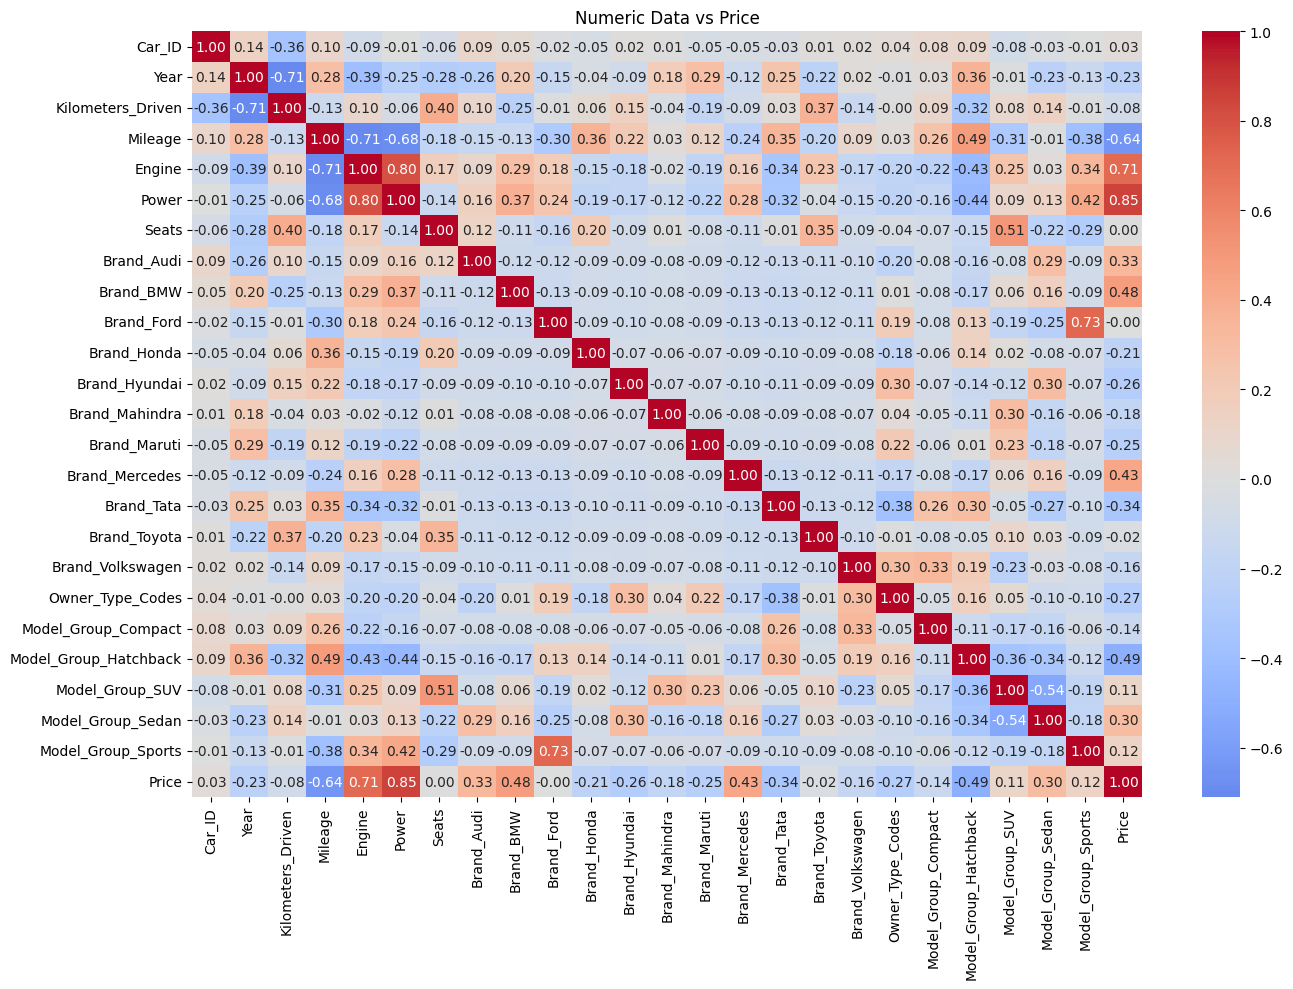

In [73]:
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Numeric Data vs Price')
plt.tight_layout()
plt.show()

З цільовою змінною Price на рівні |кореляція| > 0.5 корелюють 3 колонки:

- Power (кореляція = 0.85) — найсильніший предиктор: потужніший двигун вказує на значно вищу ціну.
- Engine (кореляція = 0.71) — більший об'єм двигуна, що логічно пов'язано з Power. Кореляція Engine-Power між собою теж висока — 0.80.
- Mileage (кореляція = -0.64) — негативну кореляцію має вища паливна ефективність (км/л), що зазвичай означає менший/економічніший двигун та нижча ціна авто.

Решта колонок (Year, Kilometers_Driven, Brand_*, Model_Group_*, Owner_Type_Codes) мають слабшу кореляцію (|кореляція| < 0.5) і не є сильними самостійними лінійними предикторами ціни, хоча деякі, наприклад Мodel_Group_Hatchback (-0.49) та Brand_Mercedes (0.43), близькі до межі.

Також можна відзначити, що Engine та Power самі між собою корелюють на 0.80 — це мультиколінеарність, тобто ці дві ознаки несуть значною мірою однакову інформацію. У подальшій побудові моделі можна розглянути використання лише однієї з них.

**Завдання 6**. Тренуємо лінійну регресію.
0. Видаліть усі НЕчислові колонки з `X_train`, `X_test`, якщо ще цього не зробили.
1. Натренуйте лінійну регресую з `sklearn` на усіх числових даних тренувального набору `X_train`.
2. Зробіть передбачення на  `X_train`, `X_test`. Знайдіть і виведіть root mean squared error відхилення передбачення від справжніх значень цільової змінної.
3. Побудуйте графік розсіювання передбачень проти реальних даних цільової змінної для тренувального і тестувального наборів даних. Що можете сказати про якість моделі?

In [74]:
# 0. Delete nonnumeric columns in X_train, X_test

X_train_numeric = X_train.select_dtypes(include=['int64', 'float64'])
X_test_numeric = X_test.select_dtypes(include=['int64', 'float64'])

print("Numeric columns:", X_train_numeric.columns.tolist())
print("Size X_train:", X_train_numeric.shape)
print("Size X_test:", X_test_numeric.shape)

Numeric columns: ['Car_ID', 'Year', 'Kilometers_Driven', 'Mileage', 'Engine', 'Power', 'Seats', 'Brand_Audi', 'Brand_BMW', 'Brand_Ford', 'Brand_Honda', 'Brand_Hyundai', 'Brand_Mahindra', 'Brand_Maruti', 'Brand_Mercedes', 'Brand_Tata', 'Brand_Toyota', 'Brand_Volkswagen', 'Owner_Type_Codes', 'Model_Group_Compact', 'Model_Group_Hatchback', 'Model_Group_SUV', 'Model_Group_Sedan', 'Model_Group_Sports']
Size X_train: (80, 24)
Size X_test: (20, 24)


In [75]:
# 1. Train Linear Regression

model = LinearRegression()
model.fit(X_train_numeric, y_train)

print("\nCoefficients:")
for col, coef in zip(X_train_numeric.columns, model.coef_):
    print(f"  {col}: {coef:.4f}")
print(f"Intercept (b): {model.intercept_:.4f}")


Coefficients:
  Car_ID: 85.5589
  Year: 62965.2414
  Kilometers_Driven: -4.3689
  Mileage: 8907.5307
  Engine: 219.4171
  Power: 5309.9332
  Seats: 106639.5892
  Brand_Audi: 803378.2313
  Brand_BMW: 775436.5478
  Brand_Ford: -41664.7899
  Brand_Honda: -332796.8319
  Brand_Hyundai: -604317.7904
  Brand_Mahindra: -587968.8132
  Brand_Maruti: -499785.4851
  Brand_Mercedes: 897038.3578
  Brand_Tata: -276584.9474
  Brand_Toyota: -39384.9202
  Brand_Volkswagen: -93349.5589
  Owner_Type_Codes: 10680.9743
  Model_Group_Compact: 122926.8142
  Model_Group_Hatchback: -305051.1767
  Model_Group_SUV: 71458.0881
  Model_Group_Sedan: 177738.7648
  Model_Group_Sports: -67072.4904
Intercept (b): -127429859.3111


In [76]:
# 2. Prediction and RMSE

def rmse(targets, predictions):
    return np.sqrt(np.mean((targets - predictions) ** 2))

predictions_train = model.predict(X_train_numeric)
predictions_test = model.predict(X_test_numeric)

rmse_train = rmse(y_train, predictions_train)
rmse_test = rmse(y_test, predictions_test)

print(f"\nRMSE on train: {rmse_train:.2f}")
print(f"RMSE on test: {rmse_test:.2f}")


RMSE on train: 228815.93
RMSE on test: 213000.72


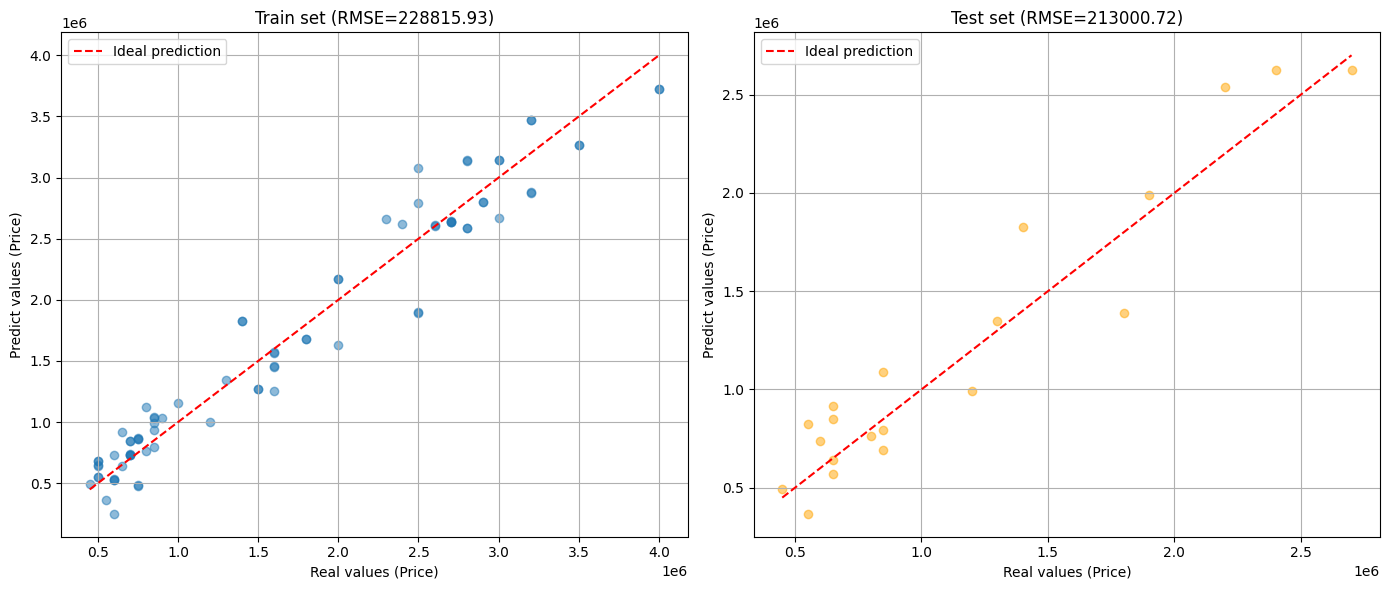

In [77]:
# 3. Predictions vs real values

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Train set
axes[0].scatter(y_train, predictions_train, alpha=0.5)
axes[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()],
             color='red', linestyle='--', label='Ideal prediction')
axes[0].set_xlabel('Real values (Price)')
axes[0].set_ylabel('Predict values (Price)')
axes[0].set_title(f'Train set (RMSE={rmse_train:.2f})')
axes[0].legend()
axes[0].grid(True)

# Test set
axes[1].scatter(y_test, predictions_test, alpha=0.5, color='orange')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
             color='red', linestyle='--', label='Ideal prediction')
axes[1].set_xlabel('Real values (Price)')
axes[1].set_ylabel('Predict values (Price)')
axes[1].set_title(f'Test set (RMSE={rmse_test:.2f})')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

## Аналіз
Модель показала схожі результати на тренувальних (RMSE=228 816) і тестових (RMSE=213 001) даних, що свідчить про відсутність перенавчання, модель добре узагальнюється на нових даних.

На обох графіках точки розташовані переважно близько до лінії ідеального передбачення, що вказує на загалом адекватну якість моделі. Водночас спостерігається тенденція до зростання похибки прогнозу для дорожчих автомобілів (вище ~2.5 млн), бо модель тут має більший розкид передбачень, що логічно враховуючи раніше виявлену сильну кореляцію ціни з Power і Engine (0.85 та 0.71), значення яких також більш розкидані для преміальних авто.

Загалом модель можна вважати прийнятною.

**Завдання 7**. Ми хочемо проаналізувати як впливає кожен чинник на цілову змінну. Для цього давайте промасштабуємо наші дані.
1. Зробіть масштабування незалежних змінних використовуючи `StandardScaler`. Тренуємо на тренувальних даних, а на тестувальних лише викликаємо `transform`.

2. Натренуйте модель на відмасштабованих даних і перегляньте коефіцієнти моделі. Які колонки є найвпливовішими на формування передбачення з точки зору коефіцієнтів? Проаналізуйте напрям дії найважливіших коефіцієнтів. Чи це логічно з точки зору значення відповідних змінних, що вони впливають на цільову змінну саме в напрямі збільшення / зменшення?

In [78]:
# 1. Scaling

scaler = StandardScaler()

scaler.fit(X_train_numeric)

X_train_scaled = scaler.transform(X_train_numeric)
X_test_scaled = scaler.transform(X_test_numeric)

# Back in DataFrame
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train_numeric.columns, index=X_train_numeric.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test_numeric.columns, index=X_test_numeric.index)

print(X_train_scaled.describe().loc[['mean', 'std']])

            Car_ID          Year  Kilometers_Driven       Mileage  \
mean -4.440892e-17  4.060086e-14       2.775558e-18  1.110223e-17   
std   1.006309e+00  1.006309e+00       1.006309e+00  1.006309e+00   

            Engine         Power         Seats    Brand_Audi     Brand_BMW  \
mean  6.661338e-17  1.776357e-16  4.662937e-16 -3.885781e-17  2.220446e-17   
std   1.006309e+00  1.006309e+00  1.006309e+00  1.006309e+00  1.006309e+00   

        Brand_Ford   Brand_Honda  Brand_Hyundai  Brand_Mahindra  Brand_Maruti  \
mean  2.220446e-17  5.551115e-17   4.996004e-17   -7.771561e-17  6.661338e-17   
std   1.006309e+00  1.006309e+00   1.006309e+00    1.006309e+00  1.006309e+00   

      Brand_Mercedes    Brand_Tata  Brand_Toyota  Brand_Volkswagen  \
mean    3.885781e-17 -4.440892e-17      0.000000     -5.551115e-18   
std     1.006309e+00  1.006309e+00      1.006309      1.006309e+00   

      Owner_Type_Codes  Model_Group_Compact  Model_Group_Hatchback  \
mean     -2.220446e-17        -9

In [79]:
# 2. Train Modell

model_scaled = LinearRegression()
model_scaled.fit(X_train_scaled, y_train)

# Coefficients
coef_df = pd.DataFrame({
    'Feature': X_train_scaled.columns,
    'Coefficient': model_scaled.coef_
})
coef_df['Abs_Coefficient'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values('Abs_Coefficient', ascending=False)

print(coef_df[['Feature', 'Coefficient']].to_string(index=False))


              Feature    Coefficient
                Power  432352.151512
       Brand_Mercedes  257111.803180
            Brand_BMW  218687.988266
           Brand_Audi  216010.419742
        Brand_Hyundai -181124.031068
       Brand_Mahindra -146309.126394
               Engine  144093.776146
         Brand_Maruti -141153.052722
Model_Group_Hatchback -125464.127744
           Brand_Tata -119035.144811
          Brand_Honda -100731.535669
                Seats   79041.087966
    Model_Group_Sedan   76292.884711
                 Year   70568.664731
     Brand_Volkswagen  -49927.514848
    Kilometers_Driven  -40061.168498
           Brand_Ford  -39500.196152
         Brand_Toyota  -36818.525707
              Mileage   30381.854160
      Model_Group_SUV   26470.404831
  Model_Group_Compact   23218.234168
   Model_Group_Sports  -20204.080862
     Owner_Type_Codes    6983.593142
               Car_ID    2418.511492


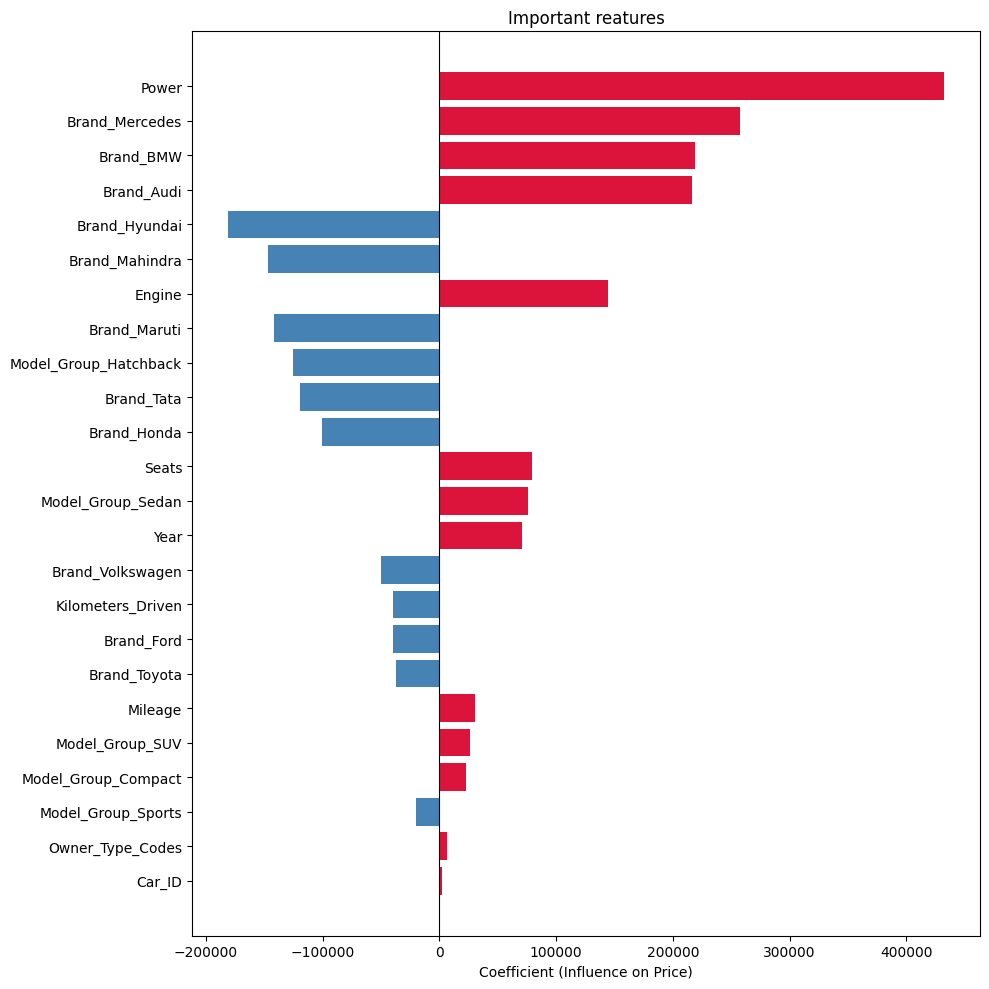

In [80]:
# Visualisation

plt.figure(figsize=(10, 10))
colors = ['crimson' if x > 0 else 'steelblue' for x in coef_df['Coefficient']]
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
plt.xlabel('Coefficient (Influence on Price)')
plt.title('Important reatures')
plt.axvline(0, color='black', linewidth=0.8)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

Найвпливовішою ознакою на ціну автомобіля є Power (потужність двигуна). Її
коефіцієнт значно перевищує всі інші, що повністю узгоджується з попереднім
кореляційним аналізом (corr=0.85).

Другий за важливістю фактор приналежність до преміум-бренду (Mercedes, BMW,
Audi). Усі мають великі позитивні коефіцієнти, що відображає типову для
автомобільного ринку "бренд-премію": покупці платять більше за бренд незалежно
від технічних характеристик. Натомість бюджетні бренди (Hyundai, Mahindra,
Maruti, Tata, Honda) мають негативні коефіцієнти.

Напрямки впливу більшості ознак логічні: вищий Year (новіше авто) і Engine
підвищують ціну, а Kilometers_Driven її знижує.

**Завдання 8.** На тих самих відмасштабованих даних натренуйте модель з `statsmodels`. Виведіть звіт і проаналізуйте p-value коефіцієнтів. Які ознаки є стат значущими на рівні значущості 0.05? Напишіть їх список.

In [81]:
# Add constant intercept
X_train_sm = sm.add_constant(X_train_scaled)

model_sm = sm.OLS(y_train, X_train_sm).fit()

print(model_sm.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.951
Model:                            OLS   Adj. R-squared:                  0.932
Method:                 Least Squares   F-statistic:                     50.30
Date:                Sun, 21 Jun 2026   Prob (F-statistic):           1.57e-29
Time:                        19:31:40   Log-Likelihood:                -1100.8
No. Observations:                  80   AIC:                             2248.
Df Residuals:                      57   BIC:                             2302.
Df Model:                          22                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                   1.68e+

In [82]:
# p-value

p_values = model_sm.pvalues.drop('const')

significant_features = p_values[p_values < 0.05].sort_values()
not_significant_features = p_values[p_values >= 0.05].sort_values()

print("Significant features (p < 0.05):")
print(significant_features)

print(f"\nCounts: {len(significant_features)} з {len(p_values)}")

print("\nNot significant features (p >= 0.05):")
print(not_significant_features)

Significant features (p < 0.05):
Brand_Mercedes           1.706680e-09
Brand_Audi               1.299800e-07
Brand_BMW                2.828270e-07
Power                    4.415224e-07
Brand_Hyundai            7.656892e-06
Brand_Mahindra           2.221657e-04
Brand_Maruti             3.644829e-04
Model_Group_Hatchback    4.517819e-03
Brand_Tata               7.240529e-03
Brand_Honda              1.034106e-02
Model_Group_Sedan        2.228376e-02
dtype: float64

Counts: 11 з 24

Not significant features (p >= 0.05):
Engine                 0.064277
Seats                  0.130997
Brand_Volkswagen       0.190944
Brand_Toyota           0.305073
Year                   0.324464
Brand_Ford             0.450178
Model_Group_SUV        0.488376
Model_Group_Compact    0.544119
Kilometers_Driven      0.573247
Mileage                0.682332
Model_Group_Sports     0.714942
Owner_Type_Codes       0.894729
Car_ID                 0.948546
dtype: float64


На рівні значущості 0.05 статистично значущими виявились 11 з 24 ознак:
Power, п'ять брендів (Mercedes, Audi, BMW, Hyundai, Mahindra, Maruti, Tata, Honda) та дві категорії типу кузова (Model_Group_Hatchback, Model_Group_Sedan).

Модель загалом дуже сильна (R²=0.951), проте варто звернути увагу на проблему
мультиколінеарності: Engine (p=0.064) і Year (p=0.324) виявились статистично
незначущими, незважаючи на високу просту кореляцію з Price (0.71 та -0.23
відповідно), через сильну взаємну кореляцію з Power (Engine-Power: 0.80) і
Kilometers_Driven (Year-Kilometers: -0.71).

Бренд автомобіля є найбільш стійким і статистично надійним фактором ціноутворення. Майже всі бренди значущі, що відображає реальну ринкову "бренд-премію", незалежну від технічних характеристик авто.

**Завдання 9**. Натренуйте лінійну регресію з `statsmodels` тільки на ознаках, які виявлись стат. значущими в попередньому завданні. Проаналізуйте показники моделі. Чи значно змінились R2 і Adj. R-squared?

In [84]:
significant_cols = [
    'Power', 'Brand_Mercedes', 'Brand_Audi', 'Brand_BMW', 'Brand_Hyundai',
    'Brand_Mahindra', 'Brand_Maruti', 'Model_Group_Hatchback',
    'Brand_Tata', 'Brand_Honda', 'Model_Group_Sedan'
]

X_train_significant = X_train_scaled[significant_cols]

X_train_significant_sm = sm.add_constant(X_train_significant)

model_significant = sm.OLS(y_train, X_train_significant_sm).fit()

print(model_significant.summary())
print(f"{'Metric':<25} {'Full modell':>25} {'Short modell':>30}")
print(f"{'R-squared':<25} {model_sm.rsquared:>25.4f} {model_significant.rsquared:>30.4f}")
print(f"{'Adj. R-squared':<25} {model_sm.rsquared_adj:>25.4f} {model_significant.rsquared_adj:>30.4f}")
print(f"{'AIC':<25} {model_sm.aic:>25.2f} {model_significant.aic:>30.2f}")
print(f"{'BIC':<25} {model_sm.bic:>25.2f} {model_significant.bic:>30.2f}")

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.937
Model:                            OLS   Adj. R-squared:                  0.927
Method:                 Least Squares   F-statistic:                     91.66
Date:                Sun, 21 Jun 2026   Prob (F-statistic):           2.63e-36
Time:                        19:40:12   Log-Likelihood:                -1111.0
No. Observations:                  80   AIC:                             2246.
Df Residuals:                      68   BIC:                             2274.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                   1.68e+

R² знизився з 0.951 до 0.937 (-0.014), що підтверджує, що видалені ознаки несли мало унікальної інформації.

Найважливіший результат — Condition Number різко впав з 1.11e16 до 3.07, що
свідчить про усунення критичної мультиколінеарності. Завдяки цьому коефіцієнти
скороченої моделі набагато надійніші й стабільніші для інтерпретації.

AIC і BIC обидва покращилися у скороченій моделі, що за цими критеріями робить
її кращим вибором ніж повна модель. Вона майже так само точна, але значно
простіша і стабільніша.

Водночас дві ознаки (Model_Group_Sedan, Brand_Honda) втратили статистичну
значущість у новій моделі — це означає, що їхня попередня "значущість" була
ймовірно артефактом мультиколінеарності з видаленими ознаками, а не реальним
ефектом.

**Завдання 10**. Натренуйте лінійну регресію з `statsmodels` на усіх ознаках з масштабованого `X_train`, у яких p_value в завданні 8 менше за `0.25`. Ми таким чином помʼякшили критерій відбору ознак. Проаналізуйте показники моделі. Чи значно змінились R2 і Adj. R-squared порівняно з завданням 8? Яку модель з останніх 3х завдань ви б лишили для використання?

In [85]:
# Features with p-value < 0.25
p_values_full = model_sm.pvalues.drop('const')
relaxed_cols = p_values_full[p_values_full < 0.25].index.tolist()

print(f"Features with p < 0.25 ({len(relaxed_cols)}):")
print(relaxed_cols)

X_train_relaxed = X_train_scaled[relaxed_cols]
X_train_relaxed_sm = sm.add_constant(X_train_relaxed)

model_relaxed = sm.OLS(y_train, X_train_relaxed_sm).fit()

print(model_relaxed.summary())

Features with p < 0.25 (14):
['Engine', 'Power', 'Seats', 'Brand_Audi', 'Brand_BMW', 'Brand_Honda', 'Brand_Hyundai', 'Brand_Mahindra', 'Brand_Maruti', 'Brand_Mercedes', 'Brand_Tata', 'Brand_Volkswagen', 'Model_Group_Hatchback', 'Model_Group_Sedan']
                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.946
Model:                            OLS   Adj. R-squared:                  0.934
Method:                 Least Squares   F-statistic:                     80.78
Date:                Sun, 21 Jun 2026   Prob (F-statistic):           1.70e-35
Time:                        19:48:27   Log-Likelihood:                -1104.9
No. Observations:                  80   AIC:                             2240.
Df Residuals:                      65   BIC:                             2276.
Df Model:                          14                                         
Covariance Type:            nonrobust   

In [86]:
print("Comparison three modells:")
print(f"{'Metric':<20} {'Full (24)':>15} {'p<0.05 (11)':>15} {'p<0.25 (' + str(len(relaxed_cols)) + ')':>15}")
print(f"{'R-squared':<20} {model_sm.rsquared:>15.4f} {model_significant.rsquared:>15.4f} {model_relaxed.rsquared:>15.4f}")
print(f"{'Adj. R-squared':<20} {model_sm.rsquared_adj:>15.4f} {model_significant.rsquared_adj:>15.4f} {model_relaxed.rsquared_adj:>15.4f}")
print(f"{'AIC':<20} {model_sm.aic:>15.2f} {model_significant.aic:>15.2f} {model_relaxed.aic:>15.2f}")
print(f"{'BIC':<20} {model_sm.bic:>15.2f} {model_significant.bic:>15.2f} {model_relaxed.bic:>15.2f}")
print(f"{'Cond. No.':<20} {model_sm.condition_number:>15.2f} {model_significant.condition_number:>15.2f} {model_relaxed.condition_number:>15.2f}")

Comparison three modells:
Metric                     Full (24)     p<0.05 (11)     p<0.25 (14)
R-squared                     0.9510          0.9368          0.9456
Adj. R-squared                0.9321          0.9266          0.9339
AIC                          2247.54         2245.90         2239.86
BIC                          2302.32         2274.49         2275.59
Cond. No.            11078746870472216.00            3.07            5.22


## Висновок

Модель з порогом p<0.25 (14 ознак) показала помітне покращення.
R² зріс з 0.9368 до 0.9456 (+0.0088), а Adjusted R² — з 0.9266 до 0.9339 (+0.0073). Зростання Adjusted R² при додаванні ознак свідчить, що додані ознаки несуть реальну корисну інформацію, а не є шумом. Тобто м'якший поріг p<0.25 дозволив повернути в модель кілька ознак (ймовірно Engine і Year, які раніше були на межі значущості p=0.064 і p=0.324 відповідно), і це покращило якість моделі.

Модель p<0.25 має найнижчий AIC (2239.86) серед усіх трьох моделей, що формально визначає її як найкращу за співвідношенням точності й складності.

Рекомендована модель для подальшого використання: p<0.25 (14 ознак), так як вона поєднує точність, близьку до повної моделі (R²=0.9456 проти 0.9510) та найкращий інформаційний критерій (AIC) серед усіх трьох варіантів.